In [ ]:
from skimage import data
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D

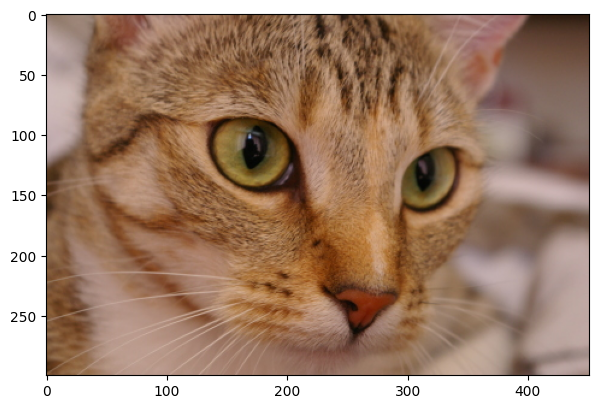

In [ ]:
image = data.cat()
plt.figure(figsize=(7, 7))
plt.imshow(image);

array([[[143, 120, 104],
        [143, 120, 104],
        [141, 118, 102],
        ...,
        [ 45,  27,  13],
        [ 45,  27,  13],
        [ 45,  27,  13]],

       [[146, 123, 107],
        [145, 122, 106],
        [143, 120, 104],
        ...,
        [ 46,  29,  13],
        [ 45,  29,  13],
        [ 47,  30,  14]],

       [[148, 126, 112],
        [147, 125, 111],
        [146, 122, 109],
        ...,
        [ 48,  28,  17],
        [ 49,  29,  18],
        [ 50,  30,  19]],

       ...,

       [[ 92,  58,  30],
        [105,  71,  43],
        [132,  98,  71],
        ...,
        [172, 145, 138],
        [172, 145, 138],
        [172, 145, 138]],

       [[128,  92,  60],
        [139, 103,  71],
        [134,  95,  64],
        ...,
        [166, 142, 132],
        [166, 142, 132],
        [167, 143, 133]],

       [[139, 103,  71],
        [127,  88,  57],
        [125,  86,  53],
        ...,
        [161, 137, 127],
        [161, 137, 127],
        [162, 138, 128]]], dtype=uint8)
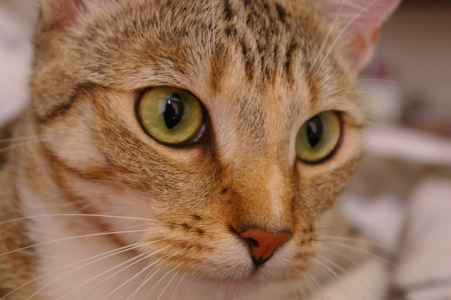

In [ ]:
image

In [ ]:
image = np.array([
    [3, 3, 2, 1, 0],
    [0, 0, 1, 3, 1],
    [3, 1, 2, 2, 3],
    [2, 0, 0, 2, 2],
    [2, 0, 0, 0, 1]
])

In [ ]:
image

array([[3, 3, 2, 1, 0],
       [0, 0, 1, 3, 1],
       [3, 1, 2, 2, 3],
       [2, 0, 0, 2, 2],
       [2, 0, 0, 0, 1]])

In [ ]:
filter = np.array([
    [0,1,2],
    [2,2,0],
    [0,1,2]
])

In [ ]:
filter

array([[0, 1, 2],
       [2, 2, 0],
       [0, 1, 2]])

In [ ]:
def conv(array, kernel):
  h, w = array.shape
  output_h = h - 2
  output_w = w - 2

  # Создаем выодной массив
  output = np.zeros((output_h, output_w))

  # Выполняем свертку
  for i in range(output_h):
    for j in range(output_w):
      # Вырезаем подмассив 3*3
      sub_array = array[i:i+3, j:j+3]
      # Вычисляем скалярное произведение
      output[i, j] = np.sum(sub_array * kernel)

  return output

In [ ]:
conv(image, filter)

array([[12., 12., 17.],
       [10., 17., 19.],
       [ 9.,  6., 14.]])

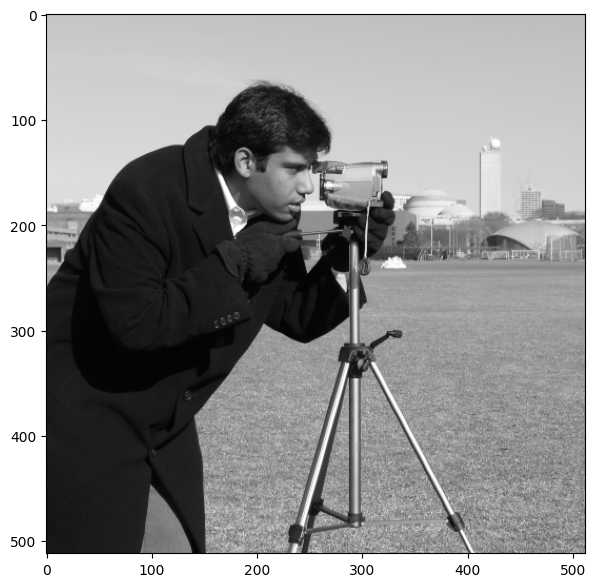

In [ ]:
image = data.camera()
plt.figure(figsize=(7, 7))
plt.imshow(image, cmap='gray');

In [ ]:
image.shape

(512, 512)

In [ ]:
image = image [None,...,None]
image.shape

(1, 512, 512, 1)

In [ ]:
image = image.astype(np.float32)

In [ ]:
conv_layer = Conv2D(kernel_size=(3,3), filters = 1)

In [ ]:
image_conv = conv_layer(image)

In [ ]:
image_conv.shape

TensorShape([1, 510, 510, 1])

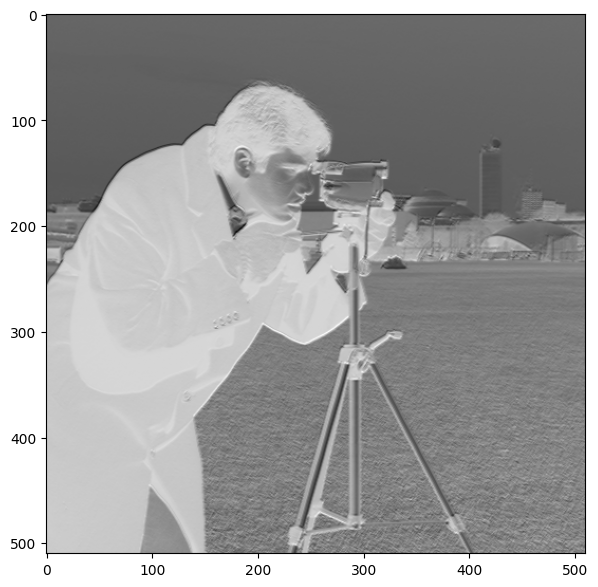

In [ ]:
plt.figure(figsize=(7, 7))
plt.imshow(image_conv[0, :, :, 0], cmap='gray');

In [ ]:
conv_layer = Conv2D(kernel_size=(3,3), filters = 1, padding='same')

In [ ]:
image_conv = conv_layer(image)

In [ ]:
image_conv.shape

TensorShape([1, 512, 512, 1])

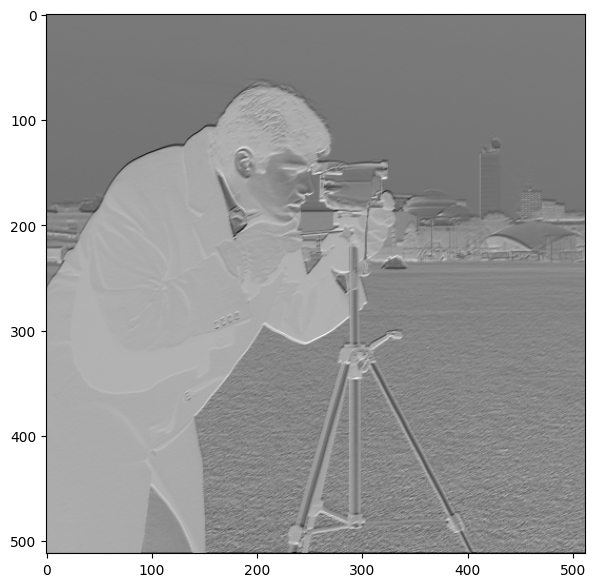

In [ ]:
plt.figure(figsize=(7,7))
plt.imshow(image_conv[0,:,:,0], cmap='gray')

# Классификация одежды

In [ ]:
mapping = {
    0: 'T-shirt/top',
    1: 'Trouser',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle boot'
}

In [ ]:
def show_mnist(images,labels, predicted_labels=None):
  plt.figure(figsize=(10,10))
  for i in range(16):
    plt.subplot(4,4,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(images[i], cmap=plt.cm.gray)
    if predicted_labels is not None:
      title_obj = plt.title(f'Real: {labels[i]}. Pred: {predicted_labels[i]}')
      if labels[i] != predicted_labels[i]:
        plt.setp(title_obj, color = 'r')
    else:
      plt.title(f'Real label: {labels[i]}')

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


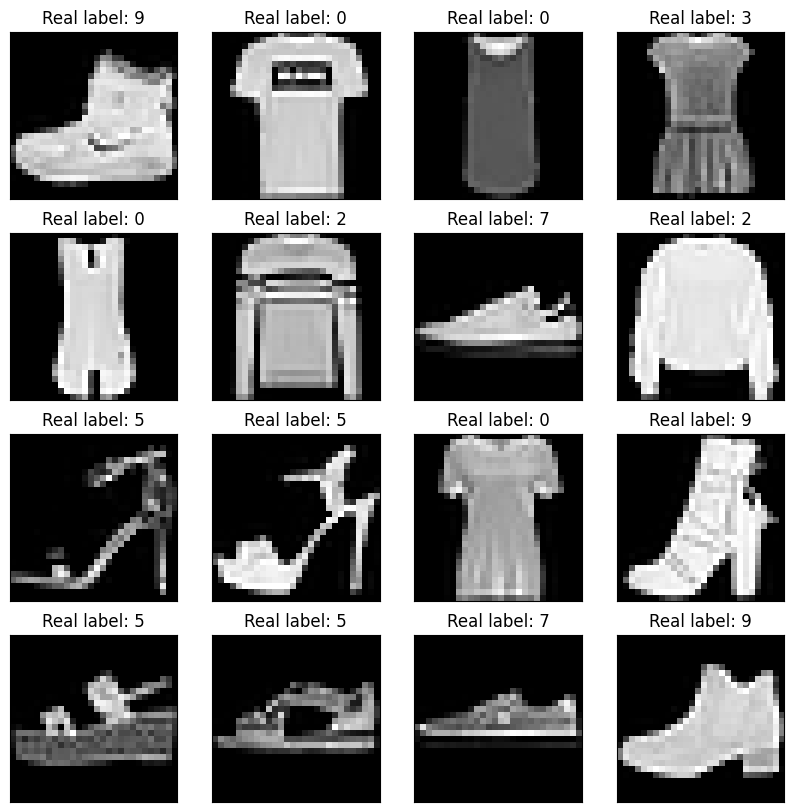

In [ ]:
show_mnist(x_train, y_train)

In [ ]:
x_train.shape

(60000, 28, 28)

In [ ]:
x_test.shape

(10000, 28, 28)